# House Price Prediction — XYlofy AI Internship Week 1

## Project Objective

The objective of this project is to build Machine Learning models that predict house prices using housing features such as area, bedrooms, bathrooms, parking, furnishing status, air conditioning, and location preferences.

## Models Used

1. Linear Regression
2. Random Forest Regressor

## Evaluation Metrics

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

In [37]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

Path("charts").mkdir(exist_ok=True)
Path("data").mkdir(exist_ok=True)

print("Libraries imported successfully.")

Libraries imported successfully.


# Day 1: Data Exploration

In [38]:
housing_df = pd.read_csv("data/Housing.csv")

print("Dataset loaded successfully.")
housing_df.head(10)

Dataset loaded successfully.


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [39]:
print("Dataset Shape")
print("-" * 30)
print(f"Rows: {housing_df.shape[0]}")
print(f"Columns: {housing_df.shape[1]}")

Dataset Shape
------------------------------
Rows: 545
Columns: 13


In [40]:
print("Column Names")
print("-" * 30)

for column in housing_df.columns:
    print(column)

Column Names
------------------------------
price
area
bedrooms
bathrooms
stories
mainroad
guestroom
basement
hotwaterheating
airconditioning
parking
prefarea
furnishingstatus


In [41]:
housing_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 69.2 KB


In [42]:
housing_df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [43]:
print("Missing Values")
print("-" * 30)

housing_df.isnull().sum()

Missing Values
------------------------------


price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [44]:
duplicates = housing_df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


In [45]:
target_column = "price"
feature_columns = [column for column in housing_df.columns if column != target_column]

print("Target Variable:", target_column)
print("Feature Columns:", feature_columns)

Target Variable: price
Feature Columns: ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']


In [46]:
categorical_columns = housing_df.select_dtypes(include=["object"]).columns

print("Categorical Columns")
print("-" * 30)

list(categorical_columns)

Categorical Columns
------------------------------


C:\Users\ASUS\AppData\Local\Temp\ipykernel_18816\3905428909.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = housing_df.select_dtypes(include=["object"]).columns


['mainroad',
 'guestroom',
 'basement',
 'hotwaterheating',
 'airconditioning',
 'prefarea',
 'furnishingstatus']

# Day 1 Findings

## Key Observations

- Dataset contains 545 records and 13 features.
- No missing values were found.
- No duplicate records were found.
- Multiple categorical features require encoding before machine learning.
- House price is the target variable.

# Day 2: Data Preprocessing

In [47]:
housing_clean = housing_df.copy()

print("Dataset copied successfully.")

Dataset copied successfully.


In [48]:
for col in categorical_columns:
    print(f"\n{col}")
    print(housing_clean[col].unique())


mainroad
<ArrowStringArray>
['yes', 'no']
Length: 2, dtype: str

guestroom
<ArrowStringArray>
['no', 'yes']
Length: 2, dtype: str

basement
<ArrowStringArray>
['no', 'yes']
Length: 2, dtype: str

hotwaterheating
<ArrowStringArray>
['no', 'yes']
Length: 2, dtype: str

airconditioning
<ArrowStringArray>
['yes', 'no']
Length: 2, dtype: str

prefarea
<ArrowStringArray>
['yes', 'no']
Length: 2, dtype: str

furnishingstatus
<ArrowStringArray>
['furnished', 'semi-furnished', 'unfurnished']
Length: 3, dtype: str


In [49]:
binary_columns = [
    "mainroad",
    "guestroom",
    "basement",
    "hotwaterheating",
    "airconditioning",
    "prefarea"
]

for col in binary_columns:
    housing_clean[col] = housing_clean[col].map({
        "yes": 1,
        "no": 0
    })

print("Binary encoding completed.")

Binary encoding completed.


In [50]:
housing_clean = pd.get_dummies(
    housing_clean,
    columns=["furnishingstatus"],
    drop_first=True,
    dtype=int
)

print("One-hot encoding completed.")

One-hot encoding completed.


In [51]:
housing_clean.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1,0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0,0


In [52]:
housing_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype
---  ------                           --------------  -----
 0   price                            545 non-null    int64
 1   area                             545 non-null    int64
 2   bedrooms                         545 non-null    int64
 3   bathrooms                        545 non-null    int64
 4   stories                          545 non-null    int64
 5   mainroad                         545 non-null    int64
 6   guestroom                        545 non-null    int64
 7   basement                         545 non-null    int64
 8   hotwaterheating                  545 non-null    int64
 9   airconditioning                  545 non-null    int64
 10  parking                          545 non-null    int64
 11  prefarea                         545 non-null    int64
 12  furnishingstatus_semi-furnished  545 non-null    int64
 13  f

In [53]:
housing_clean.to_csv(
    "data/Housing_Cleaned.csv",
    index=False
)

print("Clean dataset saved successfully.")

Clean dataset saved successfully.


# Day 2 Findings

## Key Tasks Completed

- Created a working copy of the dataset.
- Applied binary encoding to Yes/No features.
- Applied one-hot encoding to furnishing status.
- Converted categorical features into machine-learning-friendly numerical format.
- Generated a cleaned dataset for model training.

## Outcome

The dataset is now fully prepared for machine learning model development.

# Day 3: Feature Selection and Model Training

In [54]:
housing_model = pd.read_csv("data/Housing_Cleaned.csv")

housing_model.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1,0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0,0


In [55]:
X = housing_model.drop("price", axis=1)
y = housing_model["price"]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (545, 13)
Target Shape: (545,)


In [56]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data :", X_test.shape)

Training Data: (436, 13)
Testing Data : (109, 13)


In [57]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

print("Linear Regression Model Trained Successfully")

Linear Regression Model Trained Successfully


In [58]:
linear_predictions = linear_model.predict(X_test)

linear_predictions[:5]

array([5164653.90033968, 7224722.29802167, 3109863.24240338,
       4612075.3272256 , 3294646.25725956])

In [59]:
linear_mae = mean_absolute_error(y_test, linear_predictions)
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_predictions))
linear_r2 = r2_score(y_test, linear_predictions)

print("Linear Regression Results")
print("-" * 40)
print(f"MAE  : {linear_mae:,.2f}")
print(f"RMSE : {linear_rmse:,.2f}")
print(f"R²   : {linear_r2:.4f}")

Linear Regression Results
----------------------------------------
MAE  : 970,043.40
RMSE : 1,324,506.96
R²   : 0.6529


In [60]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Random Forest Trained Successfully")

Random Forest Trained Successfully


In [61]:
rf_predictions = rf_model.predict(X_test)

In [62]:
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest Results")
print("-" * 40)
print(f"MAE  : {rf_mae:,.2f}")
print(f"RMSE : {rf_rmse:,.2f}")
print(f"R²   : {rf_r2:.4f}")

Random Forest Results
----------------------------------------
MAE  : 1,022,560.05
RMSE : 1,401,496.84
R²   : 0.6114


In [63]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        linear_mae,
        rf_mae
    ],
    "RMSE": [
        linear_rmse,
        rf_rmse
    ],
    "R2 Score": [
        linear_r2,
        rf_r2
    ]
})

comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,9.700434e+05,1.324507e+06,0.652924
1,Random Forest,1.022560e+06,1.401497e+06,0.611402


# Model Performance Analysis

Linear Regression outperformed Random Forest on this dataset.

- Linear Regression had a lower MAE.
- Linear Regression had a lower RMSE.
- Linear Regression achieved a higher R² Score.

This indicates that Linear Regression explains approximately 65.3% of the variance in house prices and provides better generalization for this dataset.

Therefore, Linear Regression was selected as the best-performing model.

# Day 3 Findings

## Key Tasks Completed

- Selected features and target variable.
- Performed train-test split.
- Trained Linear Regression model.
- Trained Random Forest Regressor.
- Generated predictions on unseen data.
- Evaluated model performance using MAE, RMSE, and R² Score.

## Outcome

Both machine learning models successfully predicted house prices. Performance comparison was conducted to identify the better-performing model.

# Day 4: Data Visualization and Feature Importance

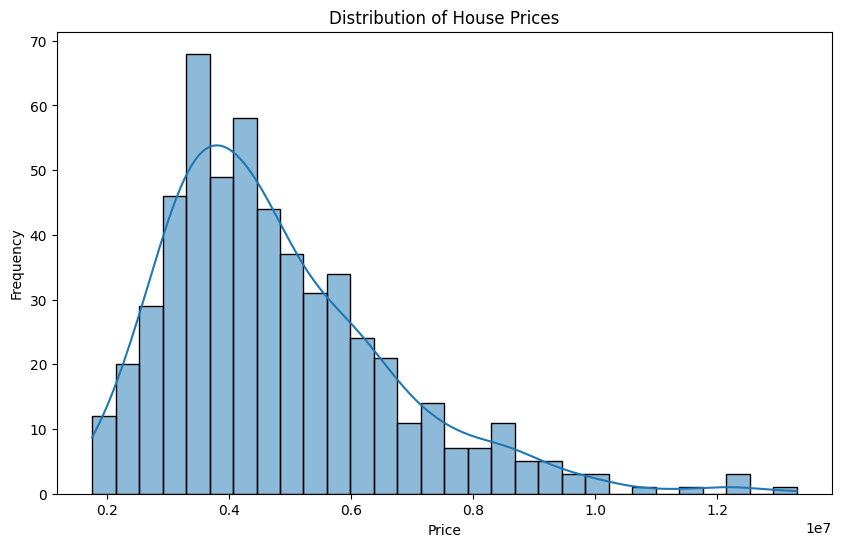

In [64]:
plt.figure(figsize=(10, 6))

sns.histplot(
    housing_model["price"],
    bins=30,
    kde=True
)

plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.savefig("charts/house_price_distribution.png", bbox_inches="tight")
plt.show()

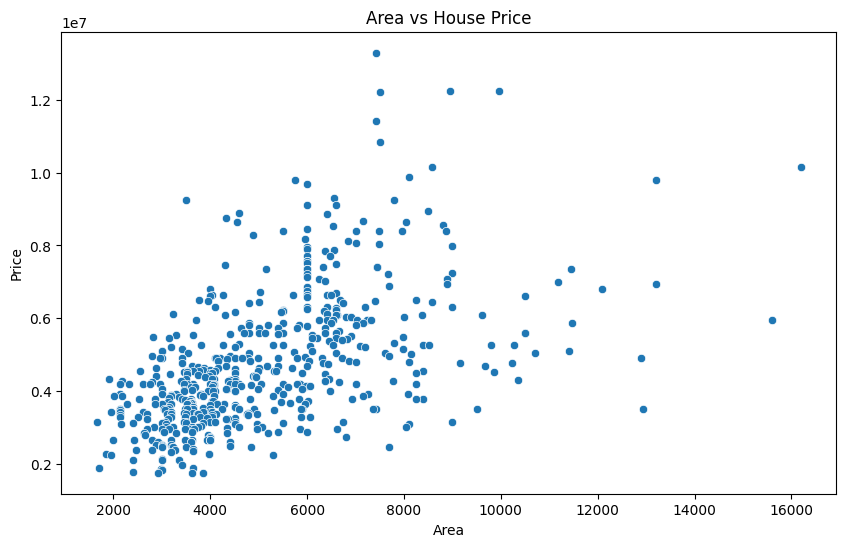

In [65]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    x=housing_model["area"],
    y=housing_model["price"]
)

plt.title("Area vs House Price")
plt.xlabel("Area")
plt.ylabel("Price")

plt.savefig("charts/area_vs_price.png", bbox_inches="tight")
plt.show()

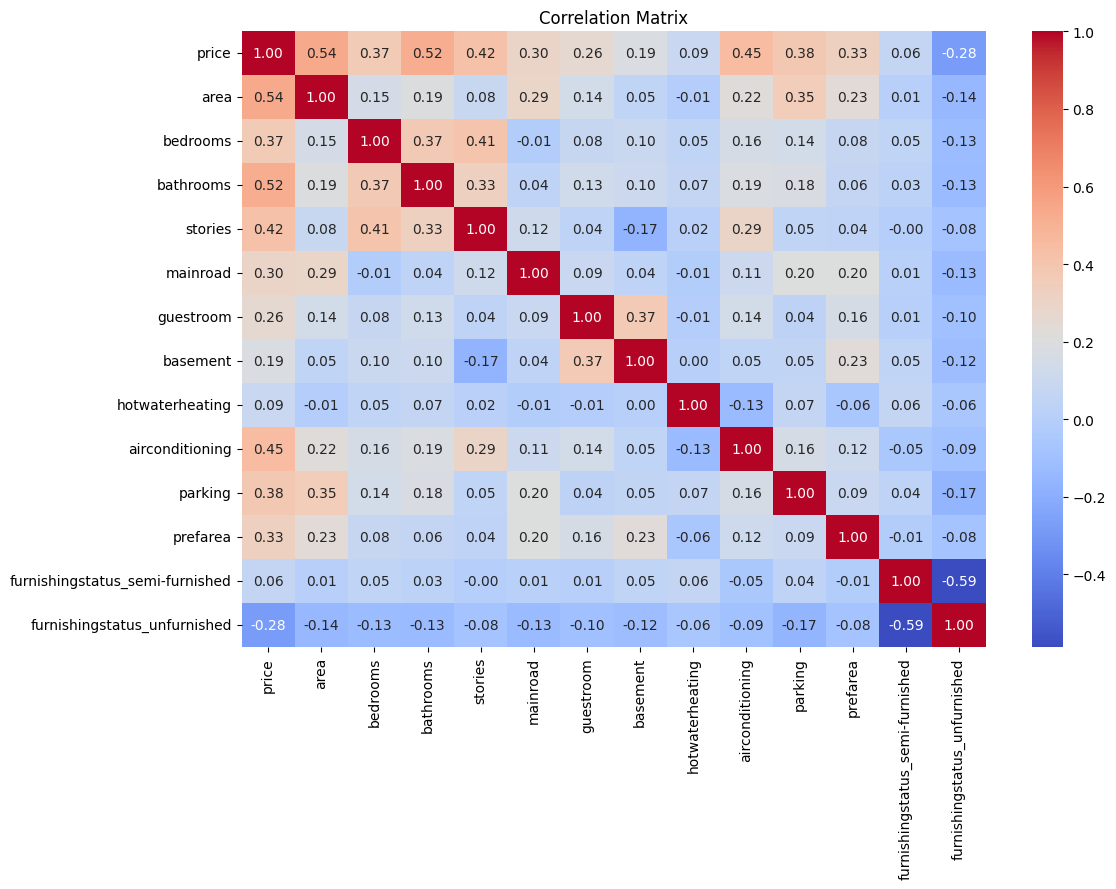

In [66]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    housing_model.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.savefig("charts/correlation_heatmap.png", bbox_inches="tight")
plt.show()

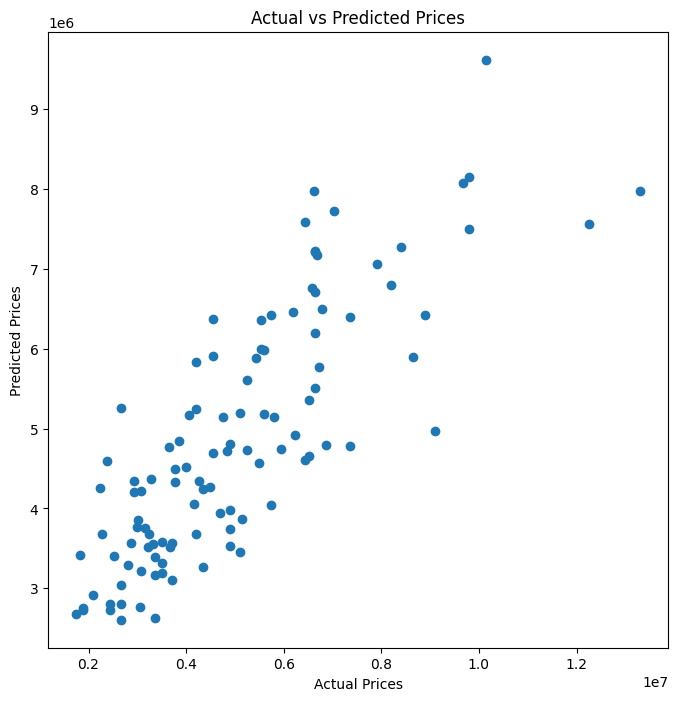

In [67]:
plt.figure(figsize=(8, 8))

plt.scatter(
    y_test,
    linear_predictions
)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices")

plt.savefig("charts/actual_vs_predicted.png", bbox_inches="tight")
plt.show()

In [68]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": linear_model.coef_
})

feature_importance = feature_importance.sort_values(
    by="Coefficient",
    ascending=False
)

feature_importance

,Feature,Coefficient
2,bathrooms,1.094445e+06
8,airconditioning,7.914267e+05
7,hotwaterheating,6.846499e+05
10,prefarea,6.298906e+05
3,stories,4.074766e+05
6,basement,3.902512e+05
4,mainroad,3.679199e+05
5,guestroom,2.316100e+05
9,parking,2.248419e+05
1,bedrooms,7.677870e+04


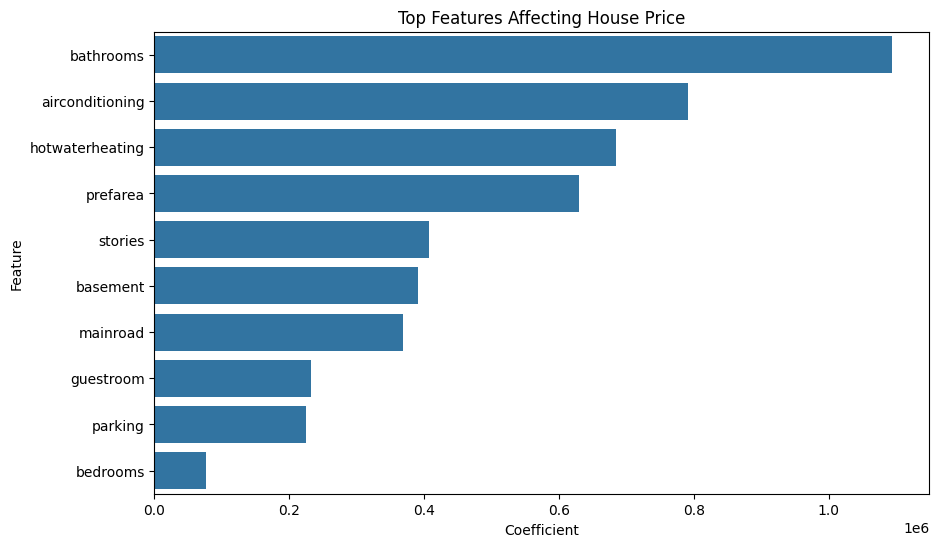

In [69]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance.head(10),
    x="Coefficient",
    y="Feature"
)

plt.title("Top Features Affecting House Price")

plt.savefig("charts/feature_importance.png", bbox_inches="tight")
plt.show()

# Day 4 Findings

## Key Visual Insights

- House prices show a right-skewed distribution.
- Property area has a positive relationship with house prices.
- Several housing amenities strongly influence price prediction.
- Linear Regression predictions closely follow actual prices.
- Bathrooms, air conditioning, hot water heating, and preferred area emerged as major contributors to house prices.

## Outcome

Visualization and feature importance analysis improved understanding of the factors driving house prices and validated the machine learning model's behavior.

# Day 5: Project Conclusion and Final Report

## Project Summary

The goal of this project was to build a machine learning model capable of predicting house prices using various housing characteristics such as area, number of bedrooms, bathrooms, amenities, and furnishing status.

## Workflow

1. Data Collection
2. Data Cleaning and Preprocessing
3. Exploratory Data Analysis
4. Feature Engineering
5. Train-Test Split
6. Model Training
7. Model Evaluation
8. Data Visualization
9. Feature Importance Analysis

## Models Implemented

- Linear Regression
- Random Forest Regressor

## Best Model

Linear Regression achieved the best overall performance on this dataset.

## Performance Metrics

| Metric | Value |
|---|---|
| MAE | 970,043 |
| RMSE | 1,324,507 |
| R² Score | 0.6529 |

The model explains approximately 65.3% of the variance in house prices.

# Business Insights

The analysis revealed that the following factors significantly influence house prices:

- Number of bathrooms
- Air conditioning availability
- Hot water heating
- Preferred residential area
- Number of stories
- Basement availability

These insights can help real estate agencies, property investors, home buyers, and housing developers make better pricing and investment decisions.

# Limitations

- Dataset size is relatively small.
- Additional market variables were unavailable.
- Location information was limited.
- Economic indicators were not included.

These factors may impact prediction accuracy.

# Future Improvements

- Collect larger datasets.
- Include geographical coordinates.
- Incorporate market trends.
- Experiment with XGBoost and LightGBM.
- Deploy the model as a web application.
- Use real-time housing data.

# Final Findings

The project successfully developed and evaluated machine learning models for house price prediction.

Among all tested models, Linear Regression delivered the best balance of accuracy and generalization.

Visualization and feature analysis confirmed that property amenities and structural characteristics play an important role in determining house prices.

The project demonstrates the complete machine learning workflow from data preparation to model evaluation and business insight generation.